In [1]:
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import replace

from src.config import SimulationConfig
from src.simulator import run_simulation
from src.disorder import generate_breakdown_strength

In [2]:
base_config = SimulationConfig(
    nx=128,
    ny=128,
    eta=1.5,
    correlation_length=5.0,
    random_seed=42,
    disorder_seed=123,
)

weibull_shapes = [2.0, 5.0, 15.0]

results = []

for k in weibull_shapes:
    config = replace(
        base_config,
        weibull_shape=k,
    )

    field, history, breakdown = run_simulation(config)

    strength = generate_breakdown_strength(
        ny=config.ny,
        nx=config.nx,
        correlation_length=config.correlation_length,
        weibull_shape=config.weibull_shape,
        seed=config.disorder_seed,
    )

    results.append(
        (config, field, history, breakdown, strength)
    )

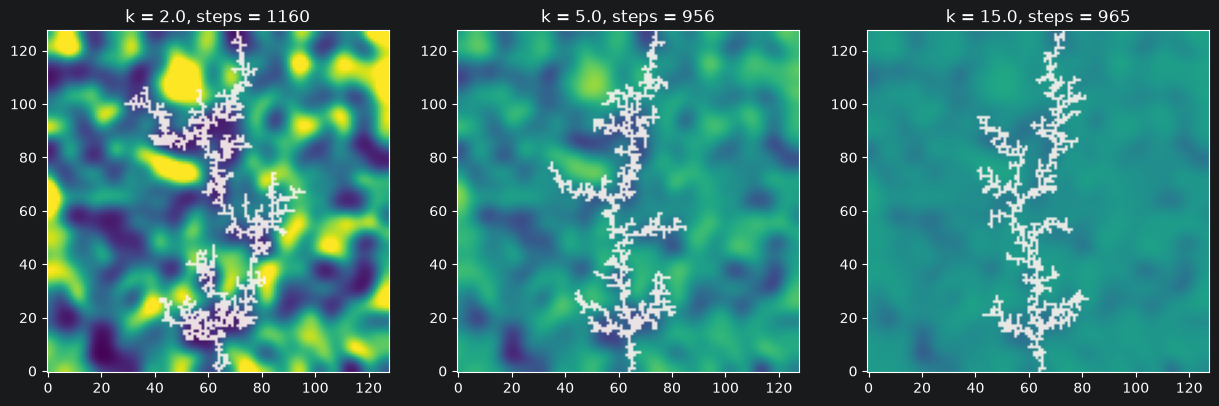

In [3]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
)

for ax, (config, field, history, breakdown, strength) in zip(
    axes,
    results,
):
    ax.imshow(
        strength,
        origin="lower",
        vmin=0.0,
        vmax=2.0,
    )

    channel = np.ma.masked_where(
        ~field.channel,
        field.channel,
    )

    ax.imshow(
        channel,
        origin="lower",
        cmap="Reds",
        alpha=0.9,
    )

    ax.set_title(
        f"k = {config.weibull_shape}, "
        f"steps = {len(history)}"
    )

plt.show()

In [4]:
for config, field, history, breakdown, strength in results:
    mean_material_strength = strength.mean()
    mean_channel_strength = strength[field.channel].mean()

    print(
        f"k={config.weibull_shape:>4}: "
        f"material={mean_material_strength:.3f}, "
        f"channel={mean_channel_strength:.3f}, "
        f"steps={len(history)}, "
        f"breakdown={breakdown}"
    )

k= 2.0: material=1.000, channel=0.654, steps=1160, breakdown=True
k= 5.0: material=1.000, channel=0.851, steps=956, breakdown=True
k=15.0: material=1.000, channel=0.951, steps=965, breakdown=True
